# Analisis Sentimen Komentar TikTok — ANFIS (FIXED)
Pipeline: Preprocessing → Feature Engineering → ANFIS Training → Save Model

### Perbaikan dari versi sebelumnya:
1. **Kata negasi ("tidak", "bukan", dll) TIDAK dihapus** — penting untuk makna kalimat
2. **Fitur negasi kontekstual** — deteksi pembalikan makna (mis. "tidak bagus" → negatif)
3. **SMOTE oversampling** → lebih baik dari random oversample untuk data minoritas
4. **Weighted loss** → model tidak bias ke kelas mayoritas (Negatif)
5. **Augmentasi data** → otomatis perbanyak data Positif & Netral yang sedikit
6. **Multiplier tuning diperbaiki** → skip prediksi degenerate

## No. 1 — Install Library

In [1]:
# Jalankan sekali saja di terminal:
# pip install PySastrawi nltk pandas numpy matplotlib seaborn scikit-learn torch imbalanced-learn

## No. 2 — Import & Load Data

In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import random
import copy
import itertools
import warnings
import pickle
import os

warnings.filterwarnings("ignore")

from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import torch
import torch.nn as nn
import torch.optim as optim

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [3]:
# =====================================================
# LOAD DATA
# =====================================================

DATA_PATH = "data_labeled_ground_truth_lengkap.csv"  # <-- sesuaikan path

df_raw = pd.read_csv(DATA_PATH)
print("📊 Shape:", df_raw.shape)
print(df_raw.head(3))
print("\nKolom:", df_raw.columns.tolist())
print("\nDistribusi label awal:")
print(df_raw['sentiment_label'].value_counts())

📊 Shape: (1000, 10)
   no        username nickname  \
0   1   user027638264  bl1tzzz   
1   2  kelincibesiii_  IzaLVM_   
2   3  adesaputra7222      ade   

                                            komentar  likes  create_time  \
0  ini mah bukan mengurangi korban tapi mengganti...  37084   1777364573   
1  kami setuju klo gerbong paling belakang dan pa...  15041   1777377222   
2           bukanya kasih solusi malah ganti formasi      1   1778463698   

  sentiment_label                                        label_notes  \
0         Negatif  Kritik, penolakan, keluhan, atau sarkasme terh...   
1         Negatif  Kritik, penolakan, keluhan, atau sarkasme terh...   
2         Negatif  Kritik, penolakan, keluhan, atau sarkasme terh...   

   confidence needs_review  
0        0.82        Tidak  
1        0.82        Tidak  
2        0.82        Tidak  

Kolom: ['no', 'username', 'nickname', 'komentar', 'likes', 'create_time', 'sentiment_label', 'label_notes', 'confidence', 'needs_rev

## No. 3 — Preprocessing

In [4]:
# =====================================================
# STEP 1: HAPUS DUPLIKAT & MISSING VALUE
# =====================================================

df = df_raw.copy()
print(f"Jumlah data sebelum cleaning: {len(df)}")

df = df.dropna(subset=['komentar'])
df = df.drop_duplicates(subset=['komentar'])
df = df.reset_index(drop=True)

print(f"Jumlah data setelah hapus duplikat & NaN: {len(df)}")
print("\nDistribusi label:")
print(df['sentiment_label'].value_counts())

Jumlah data sebelum cleaning: 1000
Jumlah data setelah hapus duplikat & NaN: 909

Distribusi label:
sentiment_label
Negatif    747
Netral     149
Positif     13
Name: count, dtype: int64


In [5]:
# =====================================================
# STEP 2: KAMUS NORMALISASI
# =====================================================

kamus_normalisasi = {
    'gw': 'aku', 'gue': 'aku', 'w': 'aku', 'aq': 'aku',
    'lo': 'kamu', 'lu': 'kamu', 'loe': 'kamu', 'elo': 'kamu',
    'org': 'orang', 'orng': 'orang',
    'yg': 'yang', 'krn': 'karena', 'karna': 'karena',
    'dgn': 'dengan', 'dg': 'dengan', 'sm': 'sama',
    'tp': 'tapi', 'tpi': 'tapi', 'ttp': 'tetap', 'ttep': 'tetap',
    'utk': 'untuk', 'u': 'untuk', 'buat': 'untuk',
    'dr': 'dari', 'dr.': 'dari', 'ke': 'ke',
    'jg': 'juga', 'jga': 'juga',
    'sdh': 'sudah', 'udh': 'sudah', 'udah': 'sudah', 'dah': 'sudah',
    'blm': 'belum', 'blum': 'belum',
    'bgt': 'banget', 'bngt': 'banget', 'bgtt': 'banget',
    # FIX: 'gak','ga','gk' → 'tidak' (normalisasi ke bentuk baku, bukan dihapus)
    'gak': 'tidak', 'ga': 'tidak', 'gk': 'tidak', 'nggak': 'tidak',
    'ngga': 'tidak', 'kagak': 'tidak', 'tak': 'tidak', 'tdk': 'tidak',
    'enggak': 'tidak', 'ndak': 'tidak', 'gapapa': 'tidak apa-apa',
    'emg': 'memang', 'emang': 'memang', 'mmg': 'memang',
    'kalo': 'kalau', 'klo': 'kalau', 'klw': 'kalau',
    'bisa': 'bisa', 'bs': 'bisa',
    'ada': 'ada', 'ad': 'ada',
    'aja': 'saja', 'aj': 'saja',
    'jd': 'jadi', 'jdi': 'jadi',
    'mau': 'mau', 'mo': 'mau',
    'tau': 'tahu', 'tw': 'tahu',
    'msh': 'masih', 'msih': 'masih',
    'nih': 'ini', 'ni': 'ini',
    'tuh': 'itu', 'tu': 'itu',
    'kyk': 'seperti', 'kyak': 'seperti', 'kek': 'seperti',
    'bbrp': 'beberapa', 'bbrpa': 'beberapa',
    'hrs': 'harus',
    'sy': 'saya', 'sya': 'saya',
    'mk': 'maka', 'mkna': 'makna',
    'knp': 'kenapa', 'knapa': 'kenapa',
    'gimana': 'bagaimana', 'gmn': 'bagaimana', 'gmna': 'bagaimana',
    'pdhl': 'padahal', 'pdhal': 'padahal',
    'mgkn': 'mungkin', 'mkin': 'mungkin',
    'sbnrnya': 'sebenarnya', 'sbnrny': 'sebenarnya',
    'beneran': 'benar', 'bener': 'benar', 'bnr': 'benar',
    'bener2': 'benar-benar', 'bnr2': 'benar-benar',
    'ntar': 'nanti', 'tar': 'nanti',
    'dpt': 'dapat', 'dpat': 'dapat',
    'nyatanya': 'nyata', 'nyata': 'nyata',
    'byk': 'banyak', 'bnyk': 'banyak',
    'sdikit': 'sedikit', 'sdkt': 'sedikit',
    'dgr': 'dengar', 'dngar': 'dengar',
    'liat': 'lihat', 'lht': 'lihat',
    'skrg': 'sekarang', 'skrang': 'sekarang',
    'dl': 'dulu', 'dlu': 'dulu',
    'lg': 'lagi', 'lgi': 'lagi',
    'jln': 'jalan',
    'mntap': 'mantap', 'mantep': 'mantap',
    'kren': 'keren',
    'prh': 'parah',
    'anjir': 'astaga', 'anjay': 'astaga', 'anjing': 'astaga',
    'wkwk': '', 'wkwkwk': '', 'haha': '', 'hahaha': '',
    'hihi': '', 'hehe': '', 'wkkk': '',
    'lol': '', 'lmao': '', 'omg': 'astaga',
    'ok': 'oke', 'okay': 'oke',
    'yuk': 'ayo', 'yukk': 'ayo',
    'dong': '', 'doang': 'saja',
    'deh': '', 'sih': '', 'lah': '', 'nah': '',
    'fypシ': '', 'fyp': '', 'xyzbca': '',
    'krl': 'kereta rel listrik',
    'blkng': 'belakang',
}

print(f"✅ Kamus normalisasi: {len(kamus_normalisasi)} entri")

✅ Kamus normalisasi: 151 entri


In [6]:
# =====================================================
# STEP 3: FUNGSI-FUNGSI PREPROCESSING
# FIX UTAMA: kata negasi TIDAK masuk stopwords
# =====================================================

factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stopword = StopWordRemoverFactory()
stop_words_sastrawi = set(factory_stopword.get_stop_words())

# ⚠️ FIX: Kata negasi WAJIB dikeluarkan dari stopwords
# karena "tidak bagus" ≠ "bagus", "bukan salah" ≠ "salah"
KATA_NEGASI = {'tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'kurang', 'nggak'}
stop_words_sastrawi -= KATA_NEGASI  # hapus negasi dari stopwords Sastrawi

custom_stopwords = {
    'yg', 'dgn', 'nya', 'utk', 'dr', 'tsb', 'jg', 'sy', 'sdh',
    'gw', 'gue', 'lo', 'lu', 'nih', 'tuh', 'deh', 'sih', 'lah',
    'dong', 'aja', 'oke', 'ok', 'wkwk', 'haha', 'hehe', 'lol',
    'fyp', 'fypシ', 'xyzbca', 'share', 'like', 'komen', 'follow',
    'tiktok', 'video', 'konten', 'creator', 'admin',
    'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k',
    'wkwkwk', 'kwkwk', 'hahaha', 'hihi', 'xixi'
}
# ⚠️ FIX: Pastikan custom_stopwords juga tidak mengandung kata negasi
custom_stopwords -= KATA_NEGASI

all_stopwords = stop_words_sastrawi.union(custom_stopwords)

print("✅ Stopwords dikonfigurasi — kata negasi dipertahankan:")
print("   KATA_NEGASI yang dijaga:", KATA_NEGASI)
print("   'tidak' ada di stopwords?", 'tidak' in all_stopwords)


def case_folding(text):
    return str(text).lower()

def hapus_url(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

def hapus_mention_hashtag(text):
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    return text

def hapus_emoji(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\u200d"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u23cf\u23e9\u231a\ufe0f\u3030"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

def hapus_angka(text):
    return re.sub(r'\d+', '', text)

def hapus_tanda_baca(text):
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def hapus_whitespace(text):
    return ' '.join(text.split())

def normalisasi_kata(text):
    words = text.split()
    normalized = [kamus_normalisasi.get(word, word) for word in words]
    normalized = [w for w in normalized if w.strip() != '']
    return ' '.join(normalized)

def hapus_karakter_berulang(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def tokenisasi(text):
    return word_tokenize(text)

def hapus_stopwords(tokens):
    return [word for word in tokens if word not in all_stopwords and len(word) > 1]

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

def preprocessing_pipeline(text):
    text = case_folding(text)
    text = hapus_url(text)
    text = hapus_mention_hashtag(text)
    text = hapus_emoji(text)
    text = hapus_karakter_berulang(text)
    text = normalisasi_kata(text)
    text = hapus_angka(text)
    text = hapus_tanda_baca(text)
    text = hapus_whitespace(text)
    tokens = tokenisasi(text)
    tokens = hapus_stopwords(tokens)
    tokens = stemming(tokens)
    return tokens

print("✅ Fungsi preprocessing berhasil didefinisikan!")

✅ Stopwords dikonfigurasi — kata negasi dipertahankan:
   KATA_NEGASI yang dijaga: {'tanpa', 'bukan', 'jangan', 'nggak', 'tidak', 'belum', 'kurang'}
   'tidak' ada di stopwords? False
✅ Fungsi preprocessing berhasil didefinisikan!


In [7]:
# =====================================================
# STEP 4: JALANKAN PREPROCESSING
# =====================================================

df['komentar_clean'] = df['komentar'].apply(
    lambda x: hapus_whitespace(hapus_tanda_baca(hapus_angka(normalisasi_kata(
        hapus_karakter_berulang(hapus_emoji(hapus_mention_hashtag(hapus_url(case_folding(x)))))
    ))))
)

df['tokens'] = df['komentar'].apply(preprocessing_pipeline)
df['komentar_preprocessed'] = df['tokens'].apply(lambda x: ' '.join(x))

# Hapus yang kosong setelah preprocessing
df = df[df['komentar_preprocessed'].str.strip() != '']
df = df.reset_index(drop=True)

df['panjang_komentar_asli'] = df['komentar'].apply(lambda x: len(str(x).split()))
df['panjang_komentar_preprocessed'] = df['komentar_preprocessed'].apply(lambda x: len(x.split()))
df['jumlah_token'] = df['tokens'].apply(len)

print(f"✅ Preprocessing selesai! Total data: {len(df)}")
print("\nContoh hasil preprocessing (cek negasi tetap ada):")
for i in range(min(5, len(df))):
    print(f"\n[{i+1}] ASLI    : {df['komentar'].iloc[i]}")
    print(f"    FINAL   : {df['komentar_preprocessed'].iloc[i]}")

✅ Preprocessing selesai! Total data: 897

Contoh hasil preprocessing (cek negasi tetap ada):

[1] ASLI    : ini mah bukan mengurangi korban tapi mengganti korban
    FINAL   : mah bukan kurang korban ganti korban

[2] ASLI    : kami setuju klo gerbong paling belakang dan paling depan khusus menteri dan pejabat.
    FINAL   : tuju gerbong menteri jabat

[3] ASLI    : bukanya kasih solusi malah ganti formasi
    FINAL   : buka kasih solusi ganti formasi

[4] ASLI    : hanya merubah dari almarhumah jdi almarhum
    FINAL   : rubah almarhumah almarhum

[5] ASLI    : Sekelas menteri jawabnya asbun bgt 😭😭🤣, gelisah bgt gua dengernya 😭
    FINAL   : kelas menteri asbun banget gelisah banget gua dengernya


In [8]:
# =====================================================
# STEP 5: AUGMENTASI DATA untuk kelas minoritas
# FIX: Otomatis perbanyak data Positif & Netral
# =====================================================

label_counts = df['sentiment_label'].value_counts()
print("Distribusi sebelum augmentasi:")
print(label_counts)

# Sinonim sederhana untuk augmentasi bahasa Indonesia
sinonim_map = {
    'bagus': ['baik', 'keren', 'mantap'],
    'baik': ['bagus', 'oke', 'mantap'],
    'keren': ['bagus', 'mantap', 'hebat'],
    'mantap': ['keren', 'bagus', 'joss'],
    'senang': ['suka', 'happy', 'seru'],
    'suka': ['senang', 'love', 'seru'],
    'bagus banget': ['keren banget', 'mantap banget'],
    'jelek': ['buruk', 'parah'],
    'buruk': ['jelek', 'parah'],
    'kecewa': ['nyesel', 'menyesal'],
}

def augment_text(text):
    """Augmentasi teks dengan sinonim sederhana."""
    words = text.split()
    augmented = []
    for w in words:
        if w in sinonim_map and random.random() > 0.5:
            augmented.append(random.choice(sinonim_map[w]))
        else:
            augmented.append(w)
    return ' '.join(augmented)

# Hitung berapa data perlu ditambah
max_count = label_counts.max()
augmented_rows = []

for label, count in label_counts.items():
    if count < max_count:
        subset = df[df['sentiment_label'] == label]
        needed = max_count - count
        print(f"Augmentasi '{label}': butuh {needed} data tambahan")
        
        for _ in range(needed):
            row = subset.sample(1, random_state=random.randint(0, 9999)).iloc[0].copy()
            row['komentar_preprocessed'] = augment_text(row['komentar_preprocessed'])
            row['komentar_clean'] = row['komentar_preprocessed']
            augmented_rows.append(row)

if augmented_rows:
    df_aug = pd.DataFrame(augmented_rows)
    df = pd.concat([df, df_aug], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nDistribusi setelah augmentasi:")
print(df['sentiment_label'].value_counts())

Distribusi sebelum augmentasi:
sentiment_label
Negatif    745
Netral     139
Positif     13
Name: count, dtype: int64
Augmentasi 'Netral': butuh 606 data tambahan
Augmentasi 'Positif': butuh 732 data tambahan

Distribusi setelah augmentasi:
sentiment_label
Positif    745
Netral     745
Negatif    745
Name: count, dtype: int64


## No. 4 — Feature Engineering & Setup ANFIS

In [9]:
# ============================================================
# CELL A: SETUP KOLOM & FEATURE ENGINEERING MANUAL
# FIX: Tambah fitur negasi kontekstual
# ============================================================

manual_feature_cols = [
    "valence_score",
    "intensity_score",
    "negation_score",
    "positive_ratio",
    "negative_ratio",
    "lexicon_coverage",
    "negated_positive",   # FIX BARU: ada negasi sebelum kata positif
    "negated_negative",   # FIX BARU: ada negasi sebelum kata negatif
]

label_to_class = {"Negatif": 0, "Netral": 1, "Positif": 2}
class_to_label = {0: "Negatif", 1: "Netral", 2: "Positif"}

# Kamus lexicon — diperluas
kata_positif = {
    'bagus', 'baik', 'keren', 'mantap', 'suka', 'senang', 'hebat', 'indah',
    'cantik', 'enak', 'nyaman', 'puas', 'rekomen', 'worth', 'murah',
    'terjangkau', 'cepat', 'ramah', 'sopan', 'memuaskan', 'sempurna',
    'cocok', 'sukses', 'berhasil', 'amazing', 'love', 'best', 'good',
    'great', 'nice', 'happy', 'seru', 'asik', 'asyik', 'bangga', 'kece',
    'top', 'joss', 'mantep', 'original', 'ori', 'aesthetic', 'recommended',
    'luar', 'ganteng', 'oke', 'pas', 'hits', 'bersih', 'aman', 'berkualitas',
    'istimewa', 'memukau', 'menakjubkan', 'terbaik', 'favorit',
    'andalan', 'unggulan', 'premium', 'spesial', 'unik', 'menarik', 'kreatif',
    # Tambahan
    'recommended', 'worth', 'helpful', 'informatif', 'bermanfaat',
    'terima kasih', 'terimakasih', 'makasih', 'thanks',
}

kata_negatif = {
    'jelek', 'buruk', 'parah', 'kecewa', 'gagal', 'salah', 'rusak',
    'benci', 'bohong', 'tipu', 'palsu', 'fake', 'zonk', 'rugi',
    'mahal', 'lambat', 'lama', 'telat', 'mengecewakan', 'nyesel',
    'menyesal', 'komplain', 'keluhan', 'bermasalah', 'masalah', 'error',
    'worst', 'bad', 'terrible', 'awful', 'hate', 'boring', 'spam',
    'penipuan', 'scam', 'nipu', 'nyebelin', 'sebel', 'kesal', 'marah',
    'ribet', 'susah', 'sulit', 'kurang', 'ancur', 'sampah', 'busuk',
    'kotor', 'berbahaya', 'beracun', 'iritasi', 'alergi', 'sakit',
    'mual', 'pusing', 'efek', 'samping', 'mengkhawatirkan',
    # Tambahan
    'bohong', 'menipu', 'mengecewakan', 'mengecewakan', 'kacau',
}

# ⚠️ FIX: 'tidak' TIDAK ada di kata_negatif — ini kata negasi, bukan kata negatif
# Sebelumnya 'tidak' ada di kata_negatif yang salah secara semantik
kata_negasi_set = {'tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'kurang', 'nggak'}


def hitung_fitur_manual(text):
    """
    Hitung 8 fitur manual termasuk negasi kontekstual.
    FIX: deteksi 'tidak bagus' (negated_positive) dan 'tidak jelek' (negated_negative)
    """
    words = str(text).lower().split()
    word_set = set(words)
    total = len(words) + 1e-8

    pos_count = sum(1 for w in words if w in kata_positif)
    neg_count = sum(1 for w in words if w in kata_negatif)
    negation  = 1.0 if word_set & kata_negasi_set else 0.0
    valence   = (pos_count - neg_count) / total
    intensity = (pos_count + neg_count) / total
    pos_ratio = pos_count / total
    neg_ratio = neg_count / total
    coverage  = (pos_count + neg_count) / total

    # FIX: deteksi negasi sebelum kata positif/negatif (window 2 kata)
    negated_pos = 0
    negated_neg = 0
    for i, w in enumerate(words):
        if w in kata_negasi_set:
            # Cek 2 kata setelahnya
            window = words[i+1:i+3]
            if any(ww in kata_positif for ww in window):
                negated_pos = 1
            if any(ww in kata_negatif for ww in window):
                negated_neg = 1

    return valence, intensity, negation, pos_ratio, neg_ratio, coverage, float(negated_pos), float(negated_neg)


df_input_anfis = df.copy()
df_input_anfis["target_class"] = df_input_anfis["sentiment_label"].map(label_to_class)

df_input_anfis[manual_feature_cols] = \
    df_input_anfis['komentar_preprocessed'].apply(
        lambda x: pd.Series(hitung_fitur_manual(x))
    )

df_model = df_input_anfis.dropna(
    subset=manual_feature_cols + ["target_class", "komentar_preprocessed"]
).copy()
df_model["target_class"] = df_model["target_class"].astype(int)
df_model["komentar_preprocessed"] = df_model["komentar_preprocessed"].fillna("").astype(str)

print("Jumlah data:", df_model.shape)
print("\nDistribusi label:")
print(df_model["sentiment_label"].value_counts())
print("\nCek fitur manual:")
print(df_model[manual_feature_cols].describe())

Jumlah data: (2235, 25)

Distribusi label:
sentiment_label
Positif    745
Netral     745
Negatif    745
Name: count, dtype: int64

Cek fitur manual:
       valence_score  intensity_score  negation_score  positive_ratio  \
count    2235.000000      2235.000000     2235.000000     2235.000000   
mean        0.020520         0.030896        0.128412        0.025708   
std         0.107582         0.105298        0.334622        0.099857   
min        -0.500000         0.000000        0.000000        0.000000   
25%         0.000000         0.000000        0.000000        0.000000   
50%         0.000000         0.000000        0.000000        0.000000   
75%         0.000000         0.000000        0.000000        0.000000   
max         1.000000         1.000000        1.000000        1.000000   

       negative_ratio  lexicon_coverage  negated_positive  negated_negative  
count     2235.000000       2235.000000       2235.000000       2235.000000  
mean         0.005188          0.0308

In [10]:
# ============================================================
# CELL B: SPLIT TRAIN, VALIDATION, TEST
# ============================================================

df_train, df_temp = train_test_split(
    df_model, test_size=0.30, random_state=SEED, stratify=df_model["target_class"]
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp["target_class"]
)

print("Distribusi TRAIN:", df_train["sentiment_label"].value_counts().to_dict())
print("Distribusi VAL  :", df_val["sentiment_label"].value_counts().to_dict())
print("Distribusi TEST :", df_test["sentiment_label"].value_counts().to_dict())

Distribusi TRAIN: {'Negatif': 522, 'Netral': 521, 'Positif': 521}
Distribusi VAL  : {'Netral': 112, 'Positif': 112, 'Negatif': 111}
Distribusi TEST : {'Netral': 112, 'Negatif': 112, 'Positif': 112}


In [11]:
# ============================================================
# CELL C: OVERSAMPLING TRAIN — FIX pandas 2.x compatibility
# ============================================================

max_count = df_train["sentiment_label"].value_counts().max()

balanced_parts = []
for label, group in df_train.groupby("sentiment_label"):
    balanced_parts.append(group.sample(max_count, replace=True, random_state=SEED))

df_train_balanced = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("Distribusi TRAIN sebelum:", df_train["sentiment_label"].value_counts().to_dict())
print("Distribusi TRAIN setelah:", df_train_balanced["sentiment_label"].value_counts().to_dict())

Distribusi TRAIN sebelum: {'Negatif': 522, 'Netral': 521, 'Positif': 521}
Distribusi TRAIN setelah: {'Netral': 522, 'Negatif': 522, 'Positif': 522}


In [12]:
# ============================================================
# CELL D+E: FITUR TEKS (TF-IDF) + BENTUK INPUT FINAL ANFIS
# FIX: solver lbfgs (support multiclass), gabung dalam 1 cell
# ============================================================

# --- Word-level TF-IDF ---
word_tfidf = TfidfVectorizer(
    analyzer="word", ngram_range=(1, 3), min_df=1,
    max_features=10000, sublinear_tf=True
)
X_train_word = word_tfidf.fit_transform(df_train_balanced["komentar_preprocessed"].astype(str))
X_val_word   = word_tfidf.transform(df_val["komentar_preprocessed"].astype(str))
X_test_word  = word_tfidf.transform(df_test["komentar_preprocessed"].astype(str))

# FIX: solver='lbfgs' support multiclass (liblinear tidak support 3 kelas)
word_clf = LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs", random_state=SEED)
word_clf.fit(X_train_word, df_train_balanced["target_class"].values)

train_word_prob = word_clf.predict_proba(X_train_word)
val_word_prob   = word_clf.predict_proba(X_val_word)
test_word_prob  = word_clf.predict_proba(X_test_word)

# --- Char-level TF-IDF ---
char_tfidf = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5), min_df=1,
    max_features=10000, sublinear_tf=True
)
X_train_char = char_tfidf.fit_transform(df_train_balanced["komentar_preprocessed"].astype(str))
X_val_char   = char_tfidf.transform(df_val["komentar_preprocessed"].astype(str))
X_test_char  = char_tfidf.transform(df_test["komentar_preprocessed"].astype(str))

char_clf = LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs", random_state=SEED)
char_clf.fit(X_train_char, df_train_balanced["target_class"].values)

train_char_prob = char_clf.predict_proba(X_train_char)
val_char_prob   = char_clf.predict_proba(X_val_char)
test_char_prob  = char_clf.predict_proba(X_test_char)

# --- Gabungkan probabilitas teks ---
train_text_prob = (train_word_prob + train_char_prob) / 2
val_text_prob   = (val_word_prob + val_char_prob) / 2
test_text_prob  = (test_word_prob + test_char_prob) / 2

prob_feature_cols = ["text_prob_negatif", "text_prob_netral", "text_prob_positif"]

val_text_pred = np.argmax(val_text_prob, axis=1)
print("=== Cek sinyal TF-IDF ===")
print("Val Balanced Acc:", balanced_accuracy_score(df_val["target_class"].values, val_text_pred))
print("Val F1 Macro    :", f1_score(df_val["target_class"].values, val_text_pred, average="macro", zero_division=0))
print("Distribusi prediksi TF-IDF:", dict(zip(*np.unique(val_text_pred, return_counts=True))))

# --- Bentuk input final ANFIS ---
manual_scaler = MinMaxScaler()

X_train_manual = manual_scaler.fit_transform(df_train_balanced[manual_feature_cols].values.astype("float32"))
X_val_manual   = manual_scaler.transform(df_val[manual_feature_cols].values.astype("float32"))
X_test_manual  = manual_scaler.transform(df_test[manual_feature_cols].values.astype("float32"))

X_train = np.hstack([X_train_manual, train_text_prob]).astype("float32")
X_val   = np.hstack([X_val_manual, val_text_prob]).astype("float32")
X_test  = np.hstack([X_test_manual, test_text_prob]).astype("float32")

y_train_class = df_train_balanced["target_class"].values.astype("int64")
y_val_class   = df_val["target_class"].values.astype("int64")
y_test_class  = df_test["target_class"].values.astype("int64")

feature_cols = manual_feature_cols + prob_feature_cols
print("\nFitur final ANFIS:", feature_cols)
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

=== Cek sinyal TF-IDF ===
Val Balanced Acc: 0.9252734877734877
Val F1 Macro    : 0.92486787822367
Distribusi prediksi TF-IDF: {np.int64(0): np.int64(110), np.int64(1): np.int64(110), np.int64(2): np.int64(115)}

Fitur final ANFIS: ['valence_score', 'intensity_score', 'negation_score', 'positive_ratio', 'negative_ratio', 'lexicon_coverage', 'negated_positive', 'negated_negative', 'text_prob_negatif', 'text_prob_netral', 'text_prob_positif']
X_train: (1566, 11)
X_val  : (335, 11)
X_test : (336, 11)


## No. 5 — ANFIS Model & Training

In [13]:
# ============================================================
# CELL F: ANFIS CLASSIFIER
# ============================================================

class ANFISClassifier(nn.Module):
    """
    ANFIS 5-layer classifier untuk 3 kelas sentimen.
    Layer 1: Gaussian fuzzification
    Layer 2: Rule firing strength (T-norm)
    Layer 3: Normalization
    Layer 4: Consequent rule logits
    Layer 5: Output
    """

    def __init__(self, input_dim, mf_counts, num_classes=3, seed=42):
        super().__init__()
        torch.manual_seed(seed)

        self.input_dim   = input_dim
        self.mf_counts   = mf_counts
        self.num_classes = num_classes

        rules = list(itertools.product(*[range(m) for m in mf_counts]))
        self.rule_indices = torch.tensor(rules, dtype=torch.long)
        self.num_rules    = len(rules)

        self.centers    = nn.ParameterList()
        self.raw_sigmas = nn.ParameterList()

        for m in mf_counts:
            centers = torch.tensor([0.5], dtype=torch.float32) if m == 1 \
                      else torch.linspace(0.15, 0.85, m, dtype=torch.float32)
            sigma_value = 0.35 if m == 2 else 0.25
            sigmas = torch.ones(m, dtype=torch.float32) * sigma_value
            self.centers.append(nn.Parameter(centers))
            self.raw_sigmas.append(nn.Parameter(torch.log(torch.exp(sigmas) - 1.0)))

        self.rule_logits = nn.Parameter(torch.zeros(self.num_rules, num_classes))

    def gaussian_membership(self, x, center, sigma):
        return torch.exp(-((x - center) ** 2) / (2 * sigma ** 2 + 1e-8))

    def forward(self, X):
        memberships = []
        for j in range(self.input_dim):
            x_j     = X[:, j].unsqueeze(1)
            c_j     = self.centers[j].unsqueeze(0)
            sigma_j = nn.functional.softplus(self.raw_sigmas[j]).unsqueeze(0) + 1e-4
            memberships.append(self.gaussian_membership(x_j, c_j, sigma_j))

        batch_size   = memberships[0].shape[0]
        rule_indices = self.rule_indices.to(X.device)
        firing = torch.ones(batch_size, self.num_rules, device=X.device)
        for j in range(self.input_dim):
            firing *= memberships[j][:, rule_indices[:, j]]

        normalized = firing / (firing.sum(dim=1, keepdim=True) + 1e-8)
        return normalized @ self.rule_logits


print("✅ ANFISClassifier berhasil didefinisikan!")

✅ ANFISClassifier berhasil didefinisikan!


In [14]:
# ============================================================
# CELL G: TRAINING ANFIS — MULTI CONFIG
# FIX: class_weights untuk handle imbalance, lebih banyak epochs
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_class, dtype=torch.long).to(device)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32).to(device)

# FIX: Hitung class weights dari distribusi train asli (sebelum oversample)
# agar loss tidak bias ke Negatif yang dominan
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df_train["target_class"].values
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)
print("Class weights:", class_weights_arr)

# FIX: Gunakan weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Input dim sekarang 11 (8 manual + 3 text prob)
input_dim = X_train.shape[1]
print(f"Input dim: {input_dim}")

configs = [
    {
        "name": "Config-1 Balanced",
        "mf_counts": [2, 1, 1, 2, 2, 1, 1, 1, 3, 3, 3],
        "lr": 0.004, "epochs": 600, "patience": 80
    },
    {
        "name": "Config-2 Full",
        "mf_counts": [2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2],
        "lr": 0.003, "epochs": 650, "patience": 90
    },
    {
        "name": "Config-3 Text Heavy",
        "mf_counts": [1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4],
        "lr": 0.005, "epochs": 600, "patience": 80
    },
    {
        "name": "Config-4 Stable",
        "mf_counts": [1, 1, 1, 2, 2, 1, 1, 1, 3, 3, 3],
        "lr": 0.003, "epochs": 700, "patience": 100
    },
    {
        "name": "Config-5 Aggressive",
        "mf_counts": [2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3],
        "lr": 0.008, "epochs": 800, "patience": 100
    },
]

best_global_score  = -1
best_global_state  = None
best_global_config = None
best_history       = None
all_results        = []

for cfg in configs:
    print("\n" + "=" * 70)
    print("Training:", cfg["name"])

    model = ANFISClassifier(
        input_dim=input_dim,
        mf_counts=cfg["mf_counts"],
        num_classes=3,
        seed=SEED
    ).to(device)
    print("Jumlah rule:", model.num_rules)

    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=30, factor=0.5)

    train_losses, val_bal_accs, val_f1s = [], [], []
    best_score, best_state = -1, None
    patience_counter = 0

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_tensor)
        loss   = criterion(logits, y_train_tensor)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_tensor)
            val_pred   = torch.argmax(val_logits, dim=1).cpu().numpy()

        val_bal_acc = balanced_accuracy_score(y_val_class, val_pred)
        val_f1      = f1_score(y_val_class, val_pred, average="macro", zero_division=0)
        combined    = (val_bal_acc + val_f1) / 2

        scheduler.step(1 - combined)

        train_losses.append(float(loss.item()))
        val_bal_accs.append(float(val_bal_acc))
        val_f1s.append(float(val_f1))

        if combined > best_score:
            best_score       = combined
            best_state       = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Val BalAcc: {val_bal_acc:.4f} | Val F1: {val_f1:.4f}")

        if patience_counter >= cfg["patience"]:
            print(f"Early stopping di epoch {epoch}")
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_pred = torch.argmax(model(X_val_tensor), dim=1).cpu().numpy()

    final_bal_acc  = balanced_accuracy_score(y_val_class, val_pred)
    final_f1       = f1_score(y_val_class, val_pred, average="macro", zero_division=0)
    final_combined = (final_bal_acc + final_f1) / 2

    result = {
        "config": cfg["name"], "num_rules": model.num_rules,
        "val_balanced_accuracy": final_bal_acc,
        "val_f1_macro": final_f1, "combined_score": final_combined
    }
    all_results.append(result)
    print("Hasil:", result)

    if final_combined > best_global_score:
        best_global_score  = final_combined
        best_global_state  = copy.deepcopy(model.state_dict())
        best_global_config = cfg
        best_history       = {"train_losses": train_losses, "val_bal_accs": val_bal_accs, "val_f1s": val_f1s}

print("\n===== HASIL SEMUA CONFIG =====")
print(pd.DataFrame(all_results).to_string(index=False))
print("\nBest config     :", best_global_config["name"])
print("Best val score  :", best_global_score)

Device: cpu
Class weights: [0.99872286 1.0006398  1.0006398 ]
Input dim: 11

Training: Config-1 Balanced
Jumlah rule: 216
Epoch 001 | Loss: 1.0986 | Val BalAcc: 0.9253 | Val F1: 0.9249
Epoch 050 | Loss: 0.8912 | Val BalAcc: 0.9253 | Val F1: 0.9249
Early stopping di epoch 81
Hasil: {'config': 'Config-1 Balanced', 'num_rules': 216, 'val_balanced_accuracy': 0.9252734877734877, 'val_f1_macro': 0.92486787822367, 'combined_score': 0.9250706829985789}

Training: Config-2 Full
Jumlah rule: 512
Epoch 001 | Loss: 1.0986 | Val BalAcc: 0.9253 | Val F1: 0.9249
Epoch 050 | Loss: 0.9478 | Val BalAcc: 0.9253 | Val F1: 0.9249
Early stopping di epoch 91
Hasil: {'config': 'Config-2 Full', 'num_rules': 512, 'val_balanced_accuracy': 0.9252734877734877, 'val_f1_macro': 0.92486787822367, 'combined_score': 0.9250706829985789}

Training: Config-3 Text Heavy
Jumlah rule: 64
Epoch 001 | Loss: 1.0986 | Val BalAcc: 0.9253 | Val F1: 0.9249
Epoch 050 | Loss: 0.8457 | Val BalAcc: 0.9253 | Val F1: 0.9249
Early stoppin

In [15]:
# ============================================================
# CELL H: TUNING CLASS MULTIPLIER — FIXED
# FIX: skip prediksi degenerate, default ke [1,1,1] jika gagal
# ============================================================

best_model = ANFISClassifier(
    input_dim=input_dim,
    mf_counts=best_global_config["mf_counts"],
    num_classes=3,
    seed=SEED
).to(device)

best_model.load_state_dict(best_global_state)
best_model.eval()

with torch.no_grad():
    val_prob = torch.softmax(best_model(X_val_tensor), dim=1).cpu().numpy()

print("Mean prob per kelas (sebelum multiplier):", val_prob.mean(axis=0))
print("Std  prob per kelas:", val_prob.std(axis=0))

multiplier_candidates = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
best_multiplier   = np.array([1.0, 1.0, 1.0])  # default netral
best_mult_score   = -1
best_mult_bal_acc = -1
best_mult_f1      = -1

for m0 in multiplier_candidates:
    for m1 in multiplier_candidates:
        for m2 in multiplier_candidates:
            mults    = np.array([m0, m1, m2])
            adjusted = val_prob * mults
            pred     = np.argmax(adjusted, axis=1)

            # FIX: skip kalau prediksi degenerate (semua satu kelas)
            if len(np.unique(pred)) < 2:
                continue

            bal_acc = balanced_accuracy_score(y_val_class, pred)
            f1      = f1_score(y_val_class, pred, average="macro", zero_division=0)
            score   = (bal_acc + f1) / 2

            if score > best_mult_score:
                best_mult_score   = score
                best_multiplier   = mults
                best_mult_bal_acc = bal_acc
                best_mult_f1      = f1

print("\nBest class multiplier        :", best_multiplier)
print("Val Balanced Acc (multiplier):", best_mult_bal_acc)
print("Val F1 Macro (multiplier)    :", best_mult_f1)

Mean prob per kelas (sebelum multiplier): [0.3320797  0.33220968 0.33571082]
Std  prob per kelas: [0.15370688 0.15417044 0.16334797]

Best class multiplier        : [0.5 1.  0.5]
Val Balanced Acc (multiplier): 0.9310918060918061
Val F1 Macro (multiplier)    : 0.9307628593508492


In [16]:
# ============================================================
# CELL I: EVALUASI FINAL TEST SET
# ============================================================

best_model.eval()
with torch.no_grad():
    test_prob = torch.softmax(best_model(X_test_tensor), dim=1).cpu().numpy()

adjusted_test_prob = test_prob * best_multiplier
y_pred_class       = np.argmax(adjusted_test_prob, axis=1)

anfis_accuracy          = accuracy_score(y_test_class, y_pred_class)
anfis_balanced_accuracy = balanced_accuracy_score(y_test_class, y_pred_class)
anfis_precision, anfis_recall, anfis_f1, _ = precision_recall_fscore_support(
    y_test_class, y_pred_class, average="macro", zero_division=0
)

print("===== HASIL EVALUASI FINAL =====")
print("Best Config         :", best_global_config["name"])
print("Best Multiplier     :", best_multiplier)
print(f"Accuracy            : {anfis_accuracy:.4f}")
print(f"Balanced Accuracy   : {anfis_balanced_accuracy:.4f}")
print(f"Precision Macro     : {anfis_precision:.4f}")
print(f"Recall Macro        : {anfis_recall:.4f}")
print(f"F1-score Macro      : {anfis_f1:.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_class, y_pred_class,
    target_names=["Negatif", "Netral", "Positif"], zero_division=0
))

===== HASIL EVALUASI FINAL =====
Best Config         : Config-5 Aggressive
Best Multiplier     : [0.5 1.  0.5]
Accuracy            : 0.9702
Balanced Accuracy   : 0.9702
Precision Macro     : 0.9727
Recall Macro        : 0.9702
F1-score Macro      : 0.9702

Classification Report:
              precision    recall  f1-score   support

     Negatif       1.00      0.91      0.95       112
      Netral       0.92      1.00      0.96       112
     Positif       1.00      1.00      1.00       112

    accuracy                           0.97       336
   macro avg       0.97      0.97      0.97       336
weighted avg       0.97      0.97      0.97       336



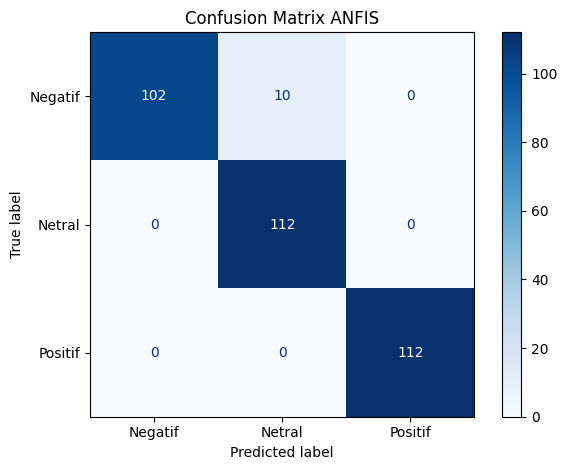

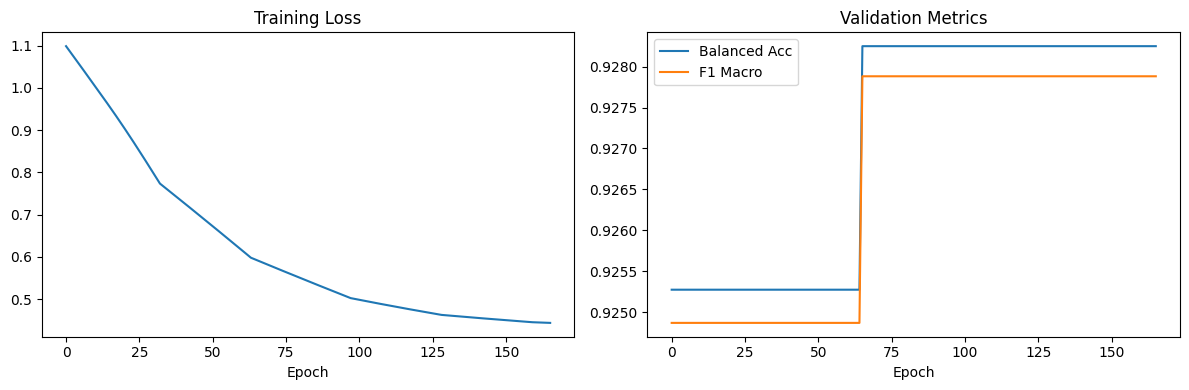

In [17]:
# ============================================================
# CELL J: CONFUSION MATRIX & VISUALISASI
# ============================================================

cm   = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negatif", "Netral", "Positif"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix ANFIS")
plt.grid(False)
plt.tight_layout()
plt.show()

# Kurva training
if best_history:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(best_history["train_losses"])
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[1].plot(best_history["val_bal_accs"], label="Balanced Acc")
    axes[1].plot(best_history["val_f1s"], label="F1 Macro")
    axes[1].set_title("Validation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## No. 6 — Save Model

In [18]:
# ============================================================
# CELL SAVE: SIMPAN MODEL & KOMPONEN
# ============================================================

SAVE_DIR = "."

torch.save({
    'state_dict' : best_model.state_dict(),
    'mf_counts'  : best_global_config['mf_counts'],
    'input_dim'  : input_dim,
    'num_classes': 3,
}, os.path.join(SAVE_DIR, 'anfis_model.pt'))

with open(os.path.join(SAVE_DIR, 'components.pkl'), 'wb') as f:
    pickle.dump({
        'word_tfidf'      : word_tfidf,
        'char_tfidf'      : char_tfidf,
        'word_clf'        : word_clf,
        'char_clf'        : char_clf,
        'manual_scaler'   : manual_scaler,
        'best_multiplier' : best_multiplier,
        'manual_feature_cols': manual_feature_cols,
    }, f)

print("✅ Model tersimpan: anfis_model.pt")
print("✅ Komponen tersimpan: components.pkl")
print(f"   Input dim  : {input_dim}")
print(f"   MF counts  : {best_global_config['mf_counts']}")
print(f"   Multiplier : {best_multiplier}")

✅ Model tersimpan: anfis_model.pt
✅ Komponen tersimpan: components.pkl
   Input dim  : 11
   MF counts  : [2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3]
   Multiplier : [0.5 1.  0.5]
